First Five Rows
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        

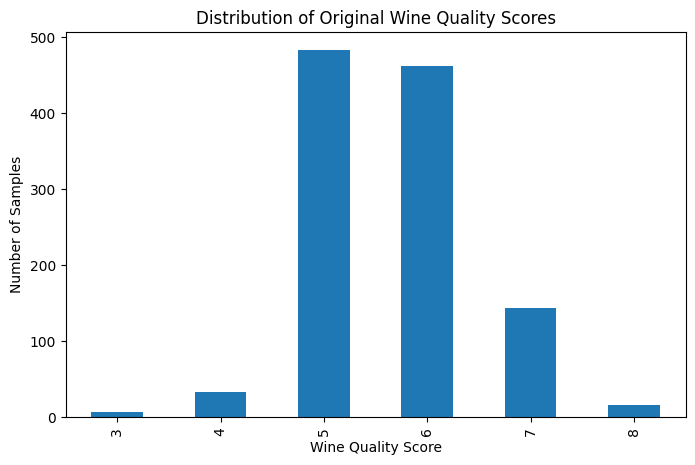


New Quality Classes
quality_label
1    621
0    522
Name: count, dtype: int64


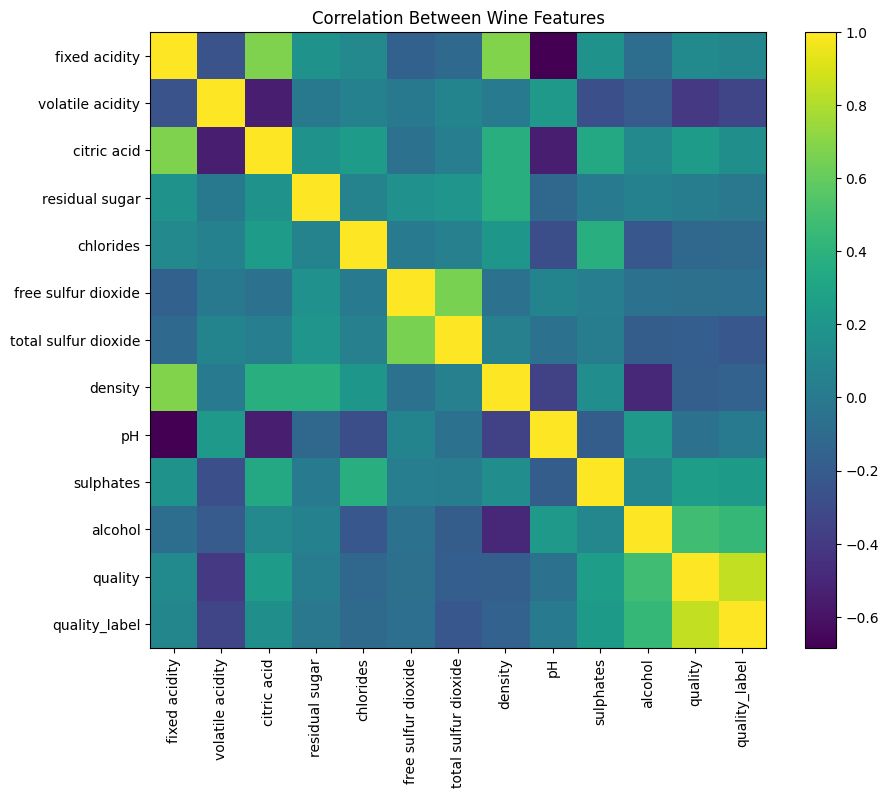

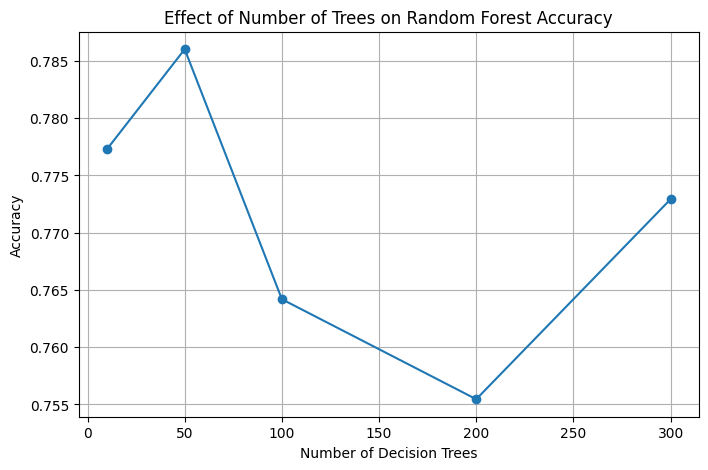

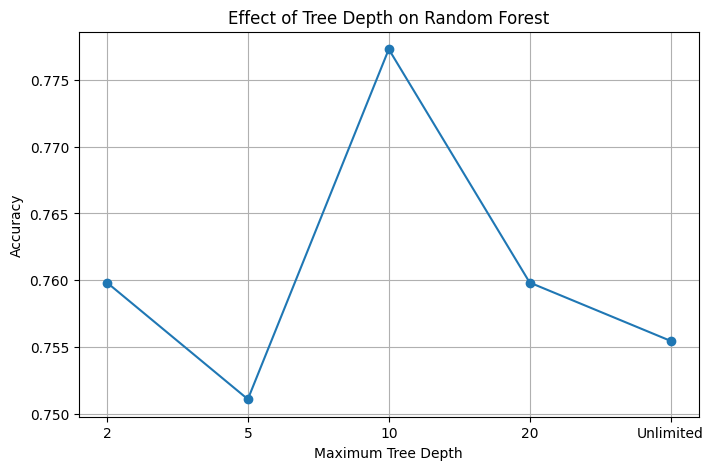


Final Accuracy:
0.759825327510917

Classification Report
              precision    recall  f1-score   support

           0       0.72      0.75      0.73       102
           1       0.79      0.77      0.78       127

    accuracy                           0.76       229
   macro avg       0.76      0.76      0.76       229
weighted avg       0.76      0.76      0.76       229


Confusion Matrix
[[76 26]
 [29 98]]


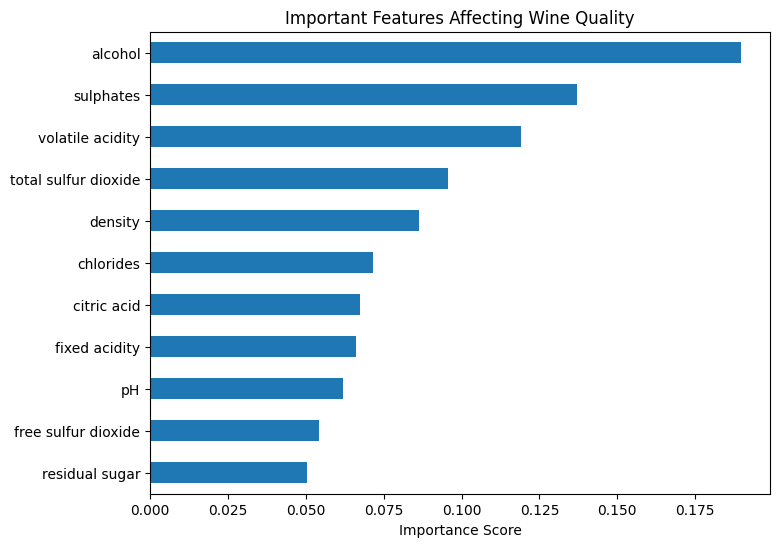

In [2]:
# ============================================================
# Random Forest Tutorial
# Wine Quality Classification
#
# Focus:
# Effect of Number of Trees and Tree Depth
# on Random Forest Performance
# ============================================================



# ============================================================
# 1. Import Libraries
# ============================================================


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split


from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)





# ============================================================
# 2. Load Dataset
# ============================================================


df = pd.read_csv("WineQT.csv")



print("First Five Rows")

print(
    df.head()
)



print("\nDataset Information")

print(
    df.info()
)



print("\nStatistical Summary")

print(
    df.describe()
)







# ============================================================
# 3. Check Missing Values
# ============================================================


print("\nMissing Values")


print(
    df.isnull().sum()
)








# ============================================================
# GRAPH 1
# Original Wine Quality Distribution
# ============================================================


plt.figure(
    figsize=(8,5)
)


df["quality"].value_counts().sort_index().plot(
    kind="bar"
)


plt.xlabel(
    "Wine Quality Score"
)


plt.ylabel(
    "Number of Samples"
)


plt.title(
    "Distribution of Original Wine Quality Scores"
)


plt.show()









# ============================================================
# 4. Data Cleaning
# ============================================================


# ID column does not contain useful information

if "Id" in df.columns:


    df = df.drop(
        "Id",
        axis=1
    )










# ============================================================
# 5. Convert Quality into Binary Classes
#
# 0 = Low Quality Wine
# 1 = High Quality Wine
# ============================================================



df["quality_label"] = df["quality"].apply(

    lambda value: 1 if value >= 6 else 0

)



print("\nNew Quality Classes")


print(

    df["quality_label"].value_counts()

)









# ============================================================
# GRAPH 2
# Correlation Heatmap
# ============================================================


plt.figure(
    figsize=(10,8)
)


plt.imshow(
    df.corr()
)


plt.colorbar()


plt.xticks(

    range(len(df.columns)),

    df.columns,

    rotation=90
)



plt.yticks(

    range(len(df.columns)),

    df.columns

)



plt.title(
    "Correlation Between Wine Features"
)



plt.show()










# ============================================================
# 6. Separate Features and Target
# ============================================================


X = df.drop(

    [
        "quality",
        "quality_label"
    ],

    axis=1

)



y = df["quality_label"]










# ============================================================
# 7. Train Test Split
# ============================================================



X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)











# ============================================================
# EXPERIMENT 1
#
# Effect of Number of Trees
# ============================================================



tree_values = [

    10,

    50,

    100,

    200,

    300

]




tree_accuracy = []





for trees in tree_values:



    model = RandomForestClassifier(

        n_estimators = trees,

        random_state = 42

    )




    model.fit(

        X_train,

        y_train

    )




    predictions = model.predict(

        X_test

    )




    score = accuracy_score(

        y_test,

        predictions

    )




    tree_accuracy.append(

        score

    )









# ============================================================
# GRAPH 3
# Number of Trees vs Accuracy
# ============================================================


plt.figure(
    figsize=(8,5)
)



plt.plot(

    tree_values,

    tree_accuracy,

    marker="o"

)



plt.xlabel(
    "Number of Decision Trees"
)



plt.ylabel(
    "Accuracy"
)



plt.title(
    "Effect of Number of Trees on Random Forest Accuracy"
)



plt.grid()



plt.show()












# ============================================================
# EXPERIMENT 2
#
# Effect of Tree Depth
# ============================================================




depth_values = [

    2,

    5,

    10,

    20,

    None

]




depth_accuracy=[]






for depth in depth_values:



    model = RandomForestClassifier(

        n_estimators=200,

        max_depth=depth,

        random_state=42

    )




    model.fit(

        X_train,

        y_train

    )




    prediction = model.predict(

        X_test

    )




    accuracy = accuracy_score(

        y_test,

        prediction

    )




    depth_accuracy.append(

        accuracy

    )










# ============================================================
# GRAPH 4
# Tree Depth vs Accuracy
# ============================================================



depth_names=[

    "2",

    "5",

    "10",

    "20",

    "Unlimited"

]




plt.figure(
    figsize=(8,5)
)




plt.plot(

    depth_names,

    depth_accuracy,

    marker="o"

)




plt.xlabel(

    "Maximum Tree Depth"

)



plt.ylabel(

    "Accuracy"

)



plt.title(

    "Effect of Tree Depth on Random Forest"

)




plt.grid()



plt.show()












# ============================================================
# 8. Final Optimized Random Forest Model
# ============================================================




final_model = RandomForestClassifier(

    n_estimators=200,

    max_depth=20,

    random_state=42

)




final_model.fit(

    X_train,

    y_train

)




final_prediction = final_model.predict(

    X_test

)






print("\nFinal Accuracy:")



print(

    accuracy_score(

        y_test,

        final_prediction

    )

)







print("\nClassification Report")




print(

classification_report(

    y_test,

    final_prediction,

    zero_division=0

)

)











# ============================================================
# Confusion Matrix
# ============================================================



print("\nConfusion Matrix")



print(

confusion_matrix(

    y_test,

    final_prediction

)

)









# ============================================================
# GRAPH 5
# Feature Importance
# ============================================================




importance = pd.Series(

    final_model.feature_importances_,

    index=X.columns

)




importance = importance.sort_values()





plt.figure(
    figsize=(8,6)
)




importance.plot(

    kind="barh"

)




plt.xlabel(

    "Importance Score"

)




plt.title(

    "Important Features Affecting Wine Quality"

)




plt.show()
